# Check correct functioning of the pipeline with openai/guided-diffusion model and new dataset

In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np

!git clone https://github.com/javiuv/GenNN-InverseMicro.git
%cd GenNN-InverseMicro/
!git checkout feature/red-diff

fatal: destination path 'GenNN-InverseMicro' already exists and is not an empty directory.
/content/GenNN-InverseMicro
M	_config/diffusion.yaml
M	_config/distortion_operator.yaml
M	_config/inference.yaml
M	main.py
M	src/architecture/diffusion.py
M	src/architecture/guided_diffusion/unet.py
M	src/operators.py
M	src/reconstruction/red_diff.py
Already on 'feature/red-diff'
Your branch is up to date with 'origin/feature/red-diff'.


## Load image

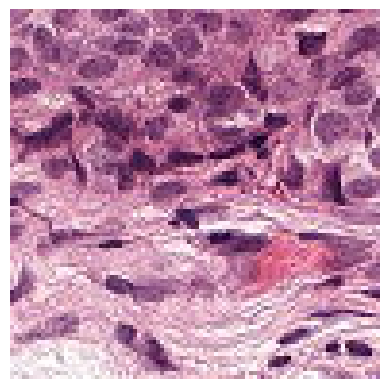

In [2]:
import torchvision.io as io

def show_tensor(tensor):
    img = (tensor.clamp(-1, 1) + 1) / 2
    img = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

imagen_tensor = io.read_image("train_0002.png")

input_image = imagen_tensor.float() / 255.
input_image = input_image*2-1
input_image = input_image.unsqueeze(0)

show_tensor(input_image)


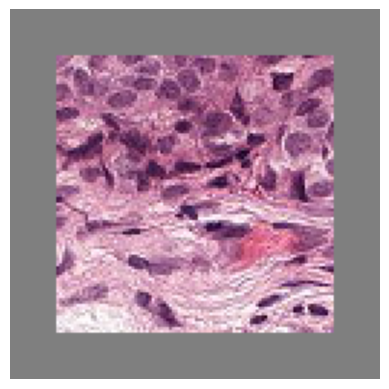

In [3]:
import torch.nn.functional as F

imagen_128 = F.pad(input_image, (16, 16, 16, 16), mode='constant', value=0)

show_tensor(imagen_128)

In [4]:
imagen_128.shape

torch.Size([1, 3, 128, 128])

## RED-diff

In [5]:
import importlib
importlib.reload(guided_diffusion)

NameError: name 'guided_diffusion' is not defined

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
path = "/content/drive/MyDrive/gnn_project/128x128_diffusion.pt"
print(f"Tamaño del archivo: {os.path.getsize(path) / 1e6:.2f} MB")

In [7]:
import gc
import torch
if 'self' in locals() and hasattr(self, 'model'):
    del self.model
torch.cuda.empty_cache()
gc.collect()

0

In [8]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
import torch
torch.cuda.empty_cache()

In [9]:
from main import run_experiment
from src.operators import Operator
import functools

torch.load = functools.partial(torch.load, weights_only=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
H = Operator(channels=3, scale_factor=2).to(device)

y_real = imagen_128.to(device)
img_noisy = H.forward(y_real)
img_recon = run_experiment(img_noisy, method='red-diff')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

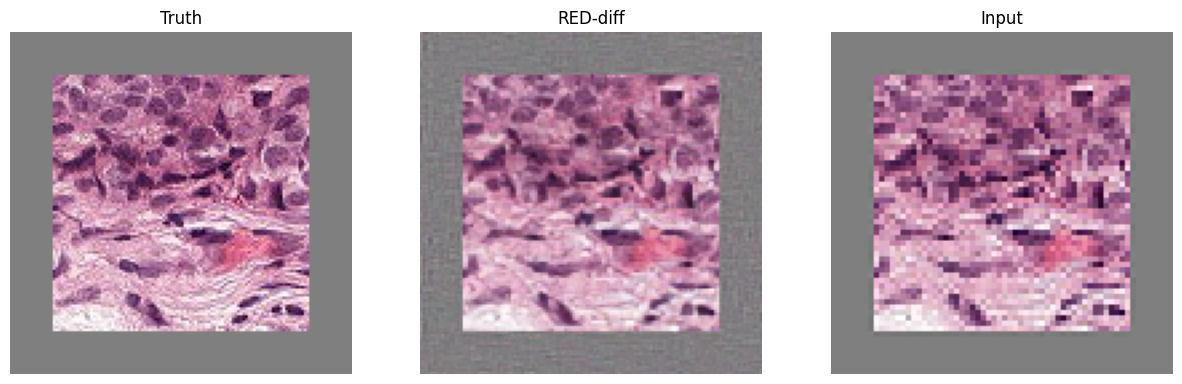

In [10]:
y_target = img_noisy
y_sol = img_recon

def show_tensor_ax(tensor, ax):
    # Preprocesamiento del tensor
    img = (tensor.clamp(-1, 1) + 1) / 2
    img = img.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Dibujar en el eje proporcionado
    ax.imshow(img)
    ax.axis('off') # Opcional: oculta los ejes para que se vea más limpio

# --- Ejemplo de uso ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

show_tensor_ax(y_real, axes[0])
axes[0].set_title("Truth")

show_tensor_ax(y_sol, axes[1])
axes[1].set_title("RED-diff")

show_tensor_ax(y_target, axes[2])
axes[2].set_title("Input")

plt.show()
